# NV Diamond Pulse Data Analysis

This notebook analyzes new measurement data from `.npy` files in the `Avg_npy_pulse` folder. Each file corresponds to one crystallographic direction in an NV- 100 faced diamond. The notebook will:
- Examine the data structure and determine the number of pixels
- Visualize time traces for each pixel and direction
- Reconstruct the 2D pixel grid (zig-zag order)
- Visualize the spatial distribution at selected time points

**Data structure:**
- Each `.npy` file: 2D array, first column is time (seconds), remaining columns are pixel voltages (units: volts or as specified)
- Four files: one per crystallographic direction

# 1. find slopes



In [154]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

results_df = pd.read_csv("results.csv")

axes_order = ["d1", "d2", "d3", "d4"]

f_left_centers_mhz = np.array([
    float(results_df.loc[results_df["name"] == "d1_f_left_meas_MHz", "value"].iloc[0]),
    float(results_df.loc[results_df["name"] == "d2_f_left_meas_MHz", "value"].iloc[0]),
    float(results_df.loc[results_df["name"] == "d3_f_left_meas_MHz", "value"].iloc[0]),
    float(results_df.loc[results_df["name"] == "d4_f_left_meas_MHz", "value"].iloc[0]),
], dtype=float)

odmr_csv_path = "/home/vita/projects/NV_sensing/data/ODMR_avg_99-6dBm_0mW.csv"

odmr_df = pd.read_csv(odmr_csv_path, sep=r"\s+")
odmr_df.columns = [c.strip() for c in odmr_df.columns]

freq_col = [c for c in odmr_df.columns if "freq" in c.lower()][0]
sig_col = [c for c in odmr_df.columns if c != freq_col][0]

f_hz_odmr = odmr_df[freq_col].to_numpy(dtype=float)
y_raw_odmr = odmr_df[sig_col].to_numpy(dtype=float)

idx = np.argsort(f_hz_odmr)
f_hz_odmr = f_hz_odmr[idx]
y_raw_odmr = y_raw_odmr[idx]

f_mhz_odmr = f_hz_odmr / 1e6
f_ghz_odmr = f_hz_odmr / 1e9

n_top = max(10, len(y_raw_odmr) // 20)
baseline_odmr = np.mean(np.sort(y_raw_odmr)[-n_top:])
S_odmr = y_raw_odmr / baseline_odmr

print("Tracked lower-transition centers [MHz]:", f_left_centers_mhz)

Tracked lower-transition centers [MHz]: [2791.20577148 2803.93502334 2855.26217136 2866.88305566]


##convert to fractional isgnal#


In [155]:

manual_windows = {
    "d1": (2788.0, 2788.9),
    "d2": (2801.0, 2801.7),
    "d3": (2852.0, 2853.0),
    "d4": (2864.0, 2865.0),
}

manual_windows

{'d1': (2788.0, 2788.9),
 'd2': (2801.0, 2801.7),
 'd3': (2852.0, 2853.0),
 'd4': (2864.0, 2865.0)}

In [156]:
slope_rows = []

for ax in axes_order:
    f_min, f_max = manual_windows[ax]
    center = f_left_centers_mhz[axes_order.index(ax)]

    mask = (f_mhz_odmr >= f_min) & (f_mhz_odmr <= f_max)

    x_fit = f_mhz_odmr[mask]
    y_fit = S_odmr[mask]

    coeffs = np.polyfit(x_fit, y_fit, deg=1)
    slope = coeffs[0]
    intercept = coeffs[1]

    y_line = slope * x_fit + intercept

    slope_rows.append({
        "axis": ax,
        "center_MHz": center,
        "fit_start_MHz": f_min,
        "fit_end_MHz": f_max,
        "slope_fraction_per_MHz": slope,
        "intercept": intercept,
        "n_points": np.sum(mask)
    })

slopes_df = pd.DataFrame(slope_rows)
display(slopes_df)

,axis,center_MHz,fit_start_MHz,fit_end_MHz,slope_fraction_per_MHz,intercept,n_points
0,d1,2791.205771,2788.0,2788.9,-0.076893,215.358173,5
1,d2,2803.935023,2801.0,2801.7,-0.087911,247.206124,4
2,d3,2855.262171,2852.0,2853.0,-0.034051,98.094483,6
3,d4,2866.883056,2864.0,2865.0,-0.022902,66.562423,6


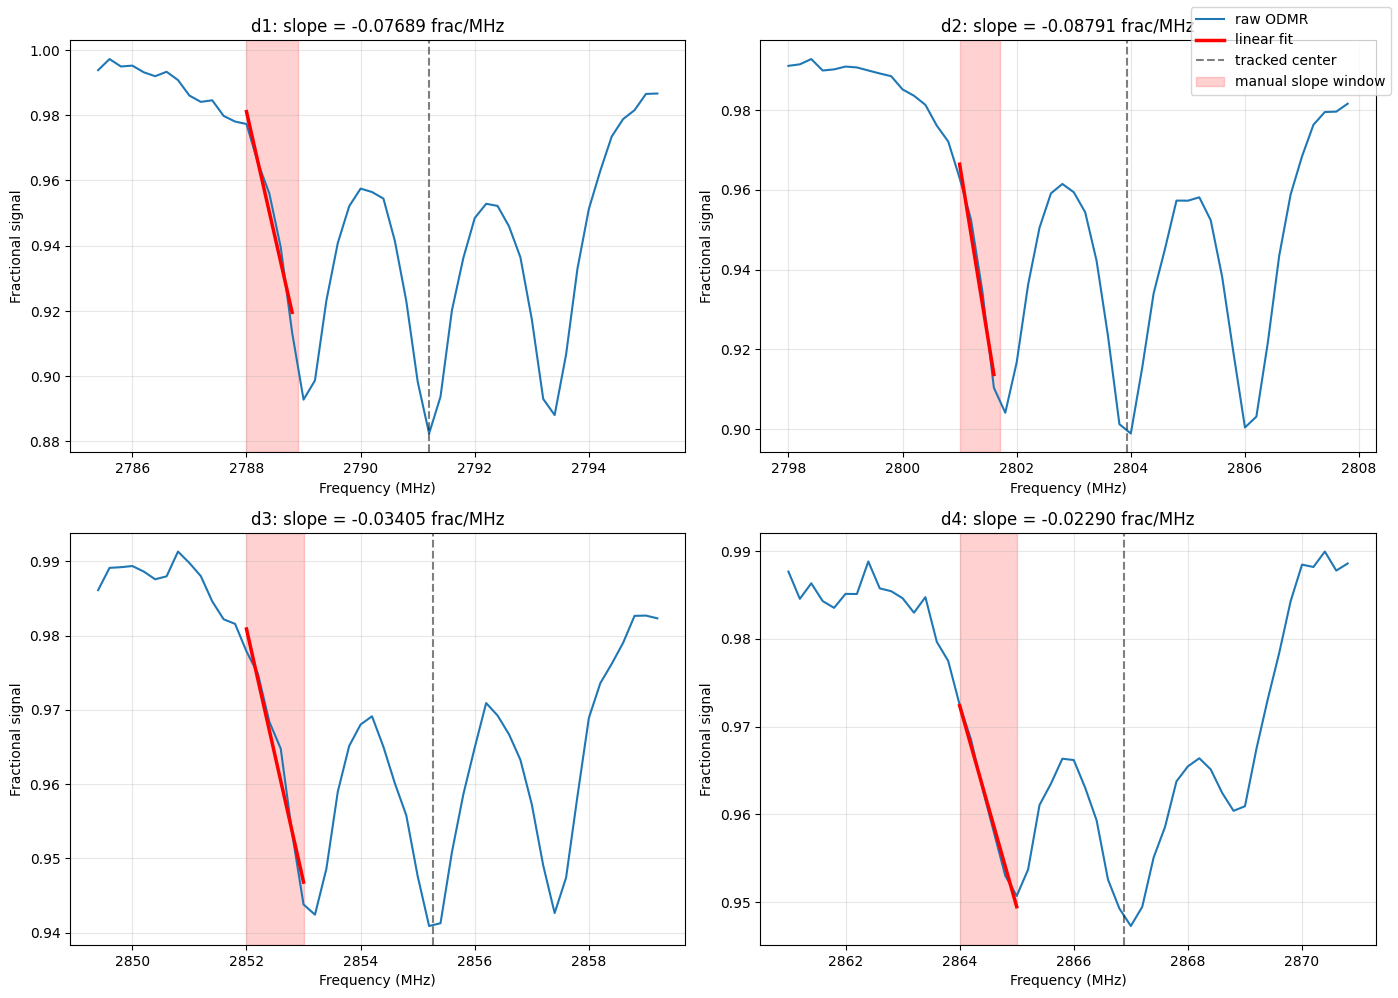

Final manually selected slopes [fractional signal per MHz]:
d1: -0.076893
d2: -0.087911
d3: -0.034051
d4: -0.022902


In [157]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

# Wider view around each tracked lower transition
left_span_mhz = 6.0
right_span_mhz = 4.0

for i, ax_name in enumerate(axes_order):
    center = slopes_df.loc[i, "center_MHz"]
    f_min = slopes_df.loc[i, "fit_start_MHz"]
    f_max = slopes_df.loc[i, "fit_end_MHz"]
    slope = slopes_df.loc[i, "slope_fraction_per_MHz"]
    intercept = slopes_df.loc[i, "intercept"]

    mask_zoom = (f_mhz_odmr >= center - left_span_mhz) & (f_mhz_odmr <= center + right_span_mhz)
    mask_fit = (f_mhz_odmr >= f_min) & (f_mhz_odmr <= f_max)

    x_fit = f_mhz_odmr[mask_fit]
    y_line = slope * x_fit + intercept

    axes[i].plot(f_mhz_odmr[mask_zoom], S_odmr[mask_zoom], lw=1.5, label="raw ODMR")
    axes[i].plot(x_fit, y_line, color="red", lw=2.5, label="linear fit")
    axes[i].axvline(center, color="k", ls="--", alpha=0.5, label="tracked center" if i == 0 else None)
    axes[i].axvspan(f_min, f_max, color="red", alpha=0.18, label="manual slope window" if i == 0 else None)

    axes[i].set_title(f"{ax_name}: slope = {slope:.5f} frac/MHz")
    axes[i].set_xlabel("Frequency (MHz)")
    axes[i].set_ylabel("Fractional signal")
    axes[i].grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
plt.tight_layout()
plt.show()

slopes_fraction_per_MHz = slopes_df["slope_fraction_per_MHz"].to_numpy(dtype=float)

print("Final manually selected slopes [fractional signal per MHz]:")
for i, ax in enumerate(axes_order):
    print(f"{ax}: {slopes_fraction_per_MHz[i]: .6f}")

## 2.  Pulse data analysis and phase selection

In [158]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load pulse data
folder = "Avg_npy_pulse"
npy_files = sorted(glob.glob(os.path.join(folder, "Pulse_avg_d*.npy")))
axes_order = ["d1", "d2", "d3", "d4"]

all_data = [np.load(f) for f in npy_files]

time = all_data[0][:, 0]
voltage_stack = np.stack([arr[:, 1:] for arr in all_data], axis=0)   # (4, Nt, 961)

n_timepoints = voltage_stack.shape[1]
n_pixels = voltage_stack.shape[2]

In [159]:
#Build gread 3131
grid_size = int(np.sqrt(n_pixels))
grid = np.zeros((grid_size, grid_size), dtype=int)

for idx in range(n_pixels):
    col = idx // grid_size
    row = idx % grid_size
    if col % 2 == 0:
        grid[grid_size - 1 - row, grid_size - 1 - col] = idx
    else:
        grid[row, grid_size - 1 - col] = idx


In [160]:
#select negative, positive and off intervals

pos_idx = 150
neg_idx = 161
off_indices = np.arange(0, 40)   # start with a conservative OFF window

V_off = np.mean(voltage_stack[:, off_indices, :], axis=1)  # (4, 961)
V_pos = voltage_stack[:, pos_idx, :]
V_neg = voltage_stack[:, neg_idx, :]

print("OFF time span [s]:", time[off_indices[0]], "to", time[off_indices[-1]])
print("POS time [s]:", time[pos_idx])
print("NEG time [s]:", time[neg_idx])

OFF time span [s]: 0.0 to 0.0150696
POS time [s]: 0.057960000000000005
NEG time [s]: 0.0622104


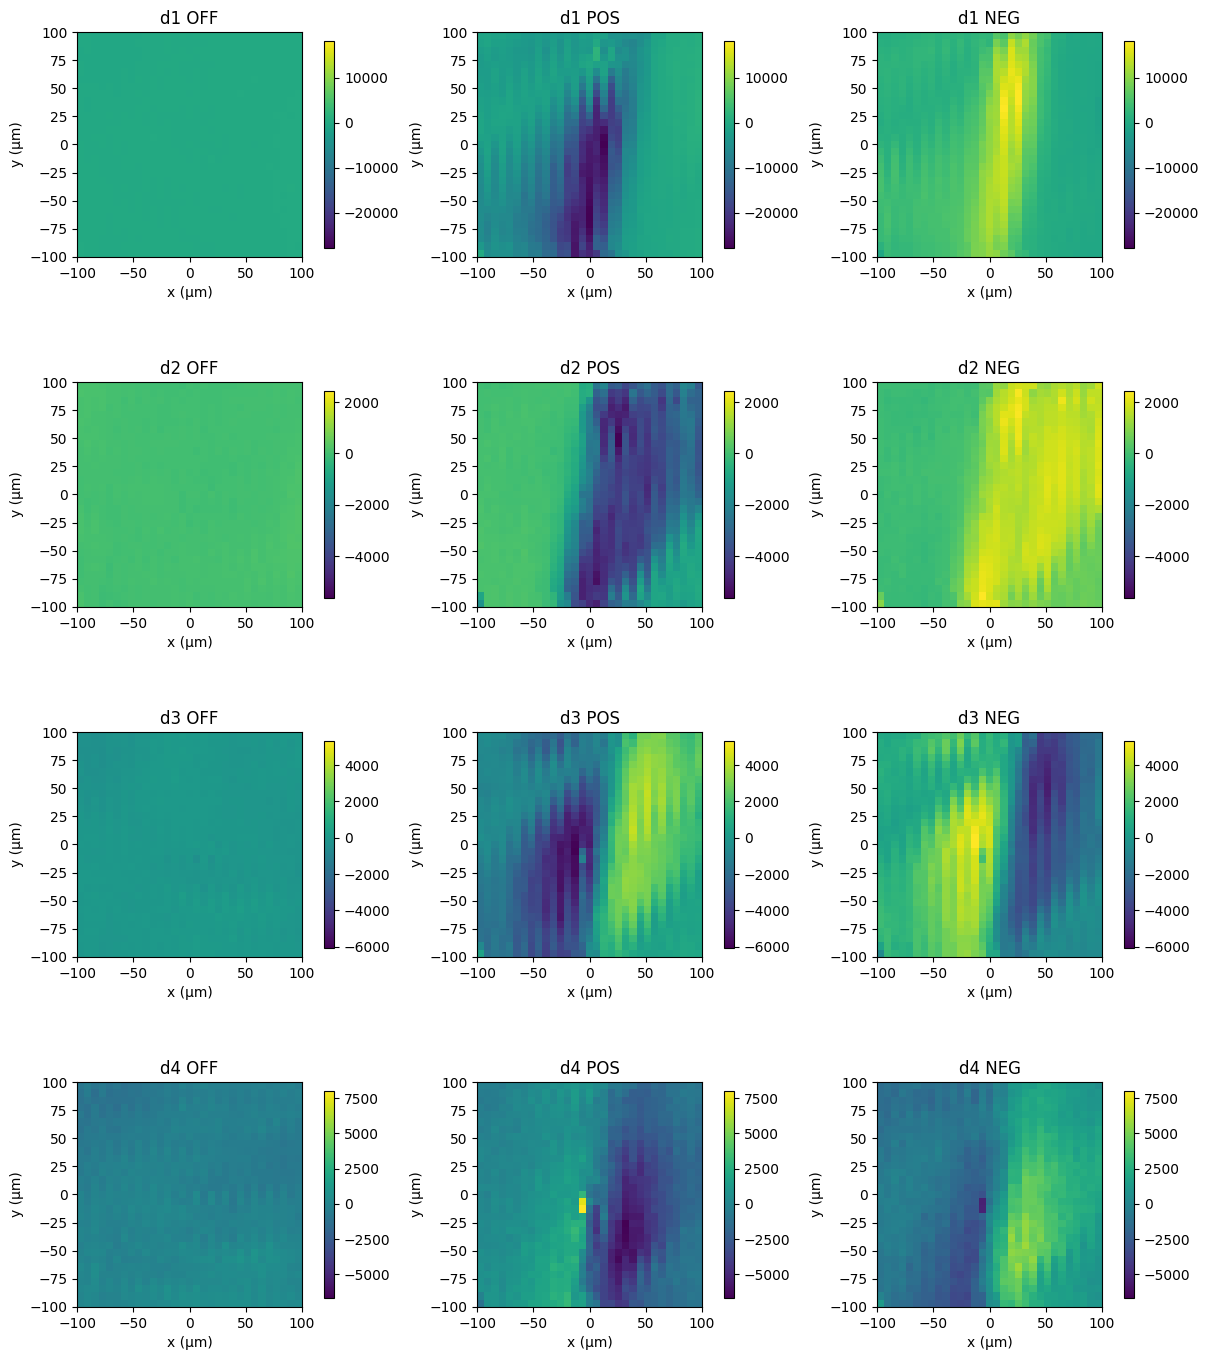

In [161]:
#raw mapsss
extent_um = [-100, 100, -100, 100]

Voff_maps = V_off[:, grid]
Vpos_maps = V_pos[:, grid]
Vneg_maps = V_neg[:, grid]


fig, axes = plt.subplots(4, 3, figsize=(12, 14), constrained_layout=True)

for i, ax_name in enumerate(axes_order):
    arrs = [Voff_maps[i], Vpos_maps[i], Vneg_maps[i]]
    titles = [f"{ax_name} OFF", f"{ax_name} POS", f"{ax_name} NEG"]

    vmin = min(np.nanmin(a) for a in arrs)
    vmax = max(np.nanmax(a) for a in arrs)

    for j in range(3):
        im = axes[i, j].imshow(
            arrs[j], extent=extent_um, origin="lower", aspect="equal",
            cmap="viridis", vmin=vmin, vmax=vmax
        )
        axes[i, j].set_title(titles[j])
        axes[i, j].set_xlabel("x (µm)")
        axes[i, j].set_ylabel("y (µm)")
        plt.colorbar(im, ax=axes[i, j], fraction=0.046, pad=0.04)

plt.show()

In [162]:
slopes_abs = np.abs(slopes_fraction_per_MHz)

deltaS_pos = np.full_like(V_pos, np.nan, dtype=float)
deltaS_neg = np.full_like(V_neg, np.nan, dtype=float)

valid_masks = []

for i, ax_name in enumerate(axes_order):
    v_off_abs = np.abs(V_off[i])
    thr = 0.05 * np.nanmedian(v_off_abs)   # 5% of median OFF magnitude
    valid = v_off_abs > thr
    valid_masks.append(valid)

    deltaS_pos[i, valid] = (V_pos[i, valid] - V_off[i, valid]) / V_off[i, valid]
    deltaS_neg[i, valid] = (V_neg[i, valid] - V_off[i, valid]) / V_off[i, valid]

    print(ax_name,
          "threshold =", thr,
          "| valid pixels =", np.sum(valid),
          "| rejected =", np.sum(~valid))

deltaNu_pos = deltaS_pos / slopes_abs[:, None]
deltaNu_neg = deltaS_neg / slopes_abs[:, None]

d1 threshold = 3.092279576069918 | valid pixels = 937 | rejected = 24
d2 threshold = 1.4333541798450935 | valid pixels = 931 | rejected = 30
d3 threshold = 3.1732397393282357 | valid pixels = 924 | rejected = 37
d4 threshold = 14.727955720538265 | valid pixels = 937 | rejected = 24


In [163]:
A_results_df = pd.read_csv("A_results.csv")

A_plus = np.zeros((3, 4), dtype=float)
for i, comp in enumerate(["Bx", "By", "Bz"]):
    for j, ax in enumerate(axes_order):
        A_plus[i, j] = float(
            A_results_df.loc[
                (A_results_df["group"] == "A_plus") &
                (A_results_df["row"] == comp) &
                (A_results_df["col"] == ax),
                "value"
            ].iloc[0]
        )

print("A_plus [mT/MHz]:\n", A_plus)

A_plus [mT/MHz]:
 [[-0.00196802 -0.00292597 -0.02287232 -0.02238438]
 [-0.02295424 -0.02253042 -0.00040755 -0.00032227]
 [-0.01562025  0.01578408 -0.01386735  0.01475487]]


In [164]:
# Reconstruct B field
# --------------------------------------------------
B_pos_mT = A_plus @ deltaNu_pos
B_neg_mT = A_plus @ deltaNu_neg

B_pos_nT = 1e6 * B_pos_mT
B_neg_nT = 1e6 * B_neg_mT

Bx_pos_map = B_pos_nT[0][grid]
By_pos_map = B_pos_nT[1][grid]
Bz_pos_map = B_pos_nT[2][grid]

Bx_neg_map = B_neg_nT[0][grid]
By_neg_map = B_neg_nT[1][grid]
Bz_neg_map = B_neg_nT[2][grid]

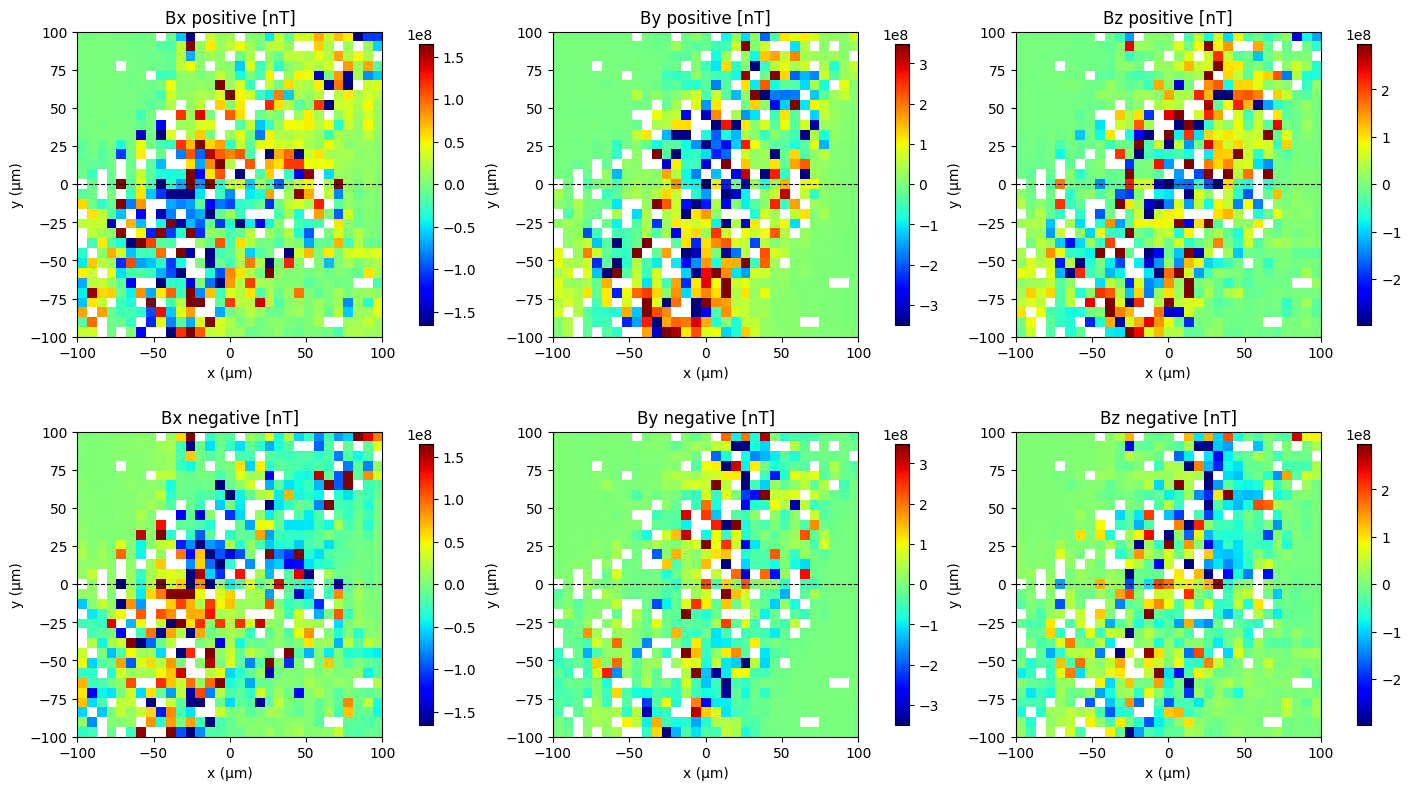

In [165]:
# --------------------------------------------------
# 9. Plot reconstructed Bx, By, Bz
# --------------------------------------------------
Bx_lim = max(np.nanpercentile(np.abs(Bx_pos_map), 95),
             np.nanpercentile(np.abs(Bx_neg_map), 95))
By_lim = max(np.nanpercentile(np.abs(By_pos_map), 95),
             np.nanpercentile(np.abs(By_neg_map), 95))
Bz_lim = max(np.nanpercentile(np.abs(Bz_pos_map), 95),
             np.nanpercentile(np.abs(Bz_neg_map), 95))

fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

maps = [
    ("Bx positive [nT]", Bx_pos_map, Bx_lim),
    ("By positive [nT]", By_pos_map, By_lim),
    ("Bz positive [nT]", Bz_pos_map, Bz_lim),
    ("Bx negative [nT]", Bx_neg_map, Bx_lim),
    ("By negative [nT]", By_neg_map, By_lim),
    ("Bz negative [nT]", Bz_neg_map, Bz_lim),
]

for ax, (title, data, lim) in zip(axes.ravel(), maps):
    if lim == 0:
        lim = 1.0
    im = ax.imshow(
        data, extent=extent_um, origin="lower", aspect="equal",
        cmap="jet", vmin=-lim, vmax=lim
    )
    ax.set_title(title)
    ax.set_xlabel("x (µm)")
    ax.set_ylabel("y (µm)")
    ax.plot([extent_um[0], extent_um[1]], [0, 0], "k--", lw=0.8)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.show()

In [166]:
for i, ax_name in enumerate(axes_order):
    print(ax_name, np.nanpercentile(np.abs(V_off[i]), [0, 1, 5, 50, 95, 99]))

for i, ax_name in enumerate(axes_order):
    print(ax_name, "max |deltaNu| [MHz] =", np.nanmax(np.abs(deltaNu_pos[i])))

d1 [4.90327269e-03 1.31150287e+00 6.38406106e+00 6.18455915e+01
 2.56311532e+02 3.24143407e+02]
d2 [1.26952939e-01 7.05664096e-01 2.47986032e+00 2.86670836e+01
 1.21241444e+02 1.84085924e+02]
d3 [3.40138796e-04 7.52659099e-01 5.23507601e+00 6.34647948e+01
 2.37221971e+02 3.46927273e+02]
d4 [4.02092475e-01 8.66784770e+00 2.49355949e+01 2.94559114e+02
 8.65883286e+02 1.15362723e+03]
d1 max |deltaNu| [MHz] = 66957.85046718577
d2 max |deltaNu| [MHz] = 28407.14794730958
d3 max |deltaNu| [MHz] = 36135.0781963801
d4 max |deltaNu| [MHz] = 11304.102808422458
